In [1]:
!pip install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented")
print("Path:", path)

data_path = os.path.join(path, "combined_images")
print(os.listdir(data_path))

100%|██████████| 398M/398M [00:02<00:00, 155MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/versions/1
['ModerateDemented', 'VeryMildDemented', 'MildDemented', 'NonDemented']


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,          # ✅ correct for ANN
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 35200 images belonging to 4 classes.
Found 8800 images belonging to 4 classes.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model_ann = Sequential([
    Input(shape=(224,224,3)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

model_ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,276,228 (73.53 MB)

 Trainable params: 19,276,228 (73.53 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history_ann = model_ann.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 438s 398ms/step - accuracy: 0.6225 - loss: 0.8347 - val_accuracy: 0.5107 - val_loss: 1.0428
Epoch 2/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 441s 401ms/step - accuracy: 0.6303 - loss: 0.8217 - val_accuracy: 0.6283 - val_loss: 0.8169
Epoch 3/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 431s 392ms/step - accuracy: 0.6196 - loss: 0.8561 - val_accuracy: 0.6058 - val_loss: 0.8573
Epoch 4/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 436s 396ms/step - accuracy: 0.6470 - loss: 0.7887 - val_accuracy: 0.5585 - val_loss: 0.9410
Epoch 5/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 436s 397ms/step - accuracy: 0.6557 - loss: 0.7693 - val_accuracy: 0.6281 - val_loss: 0.8754


Found 8800 images belonging to 4 classes.
275/275 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step


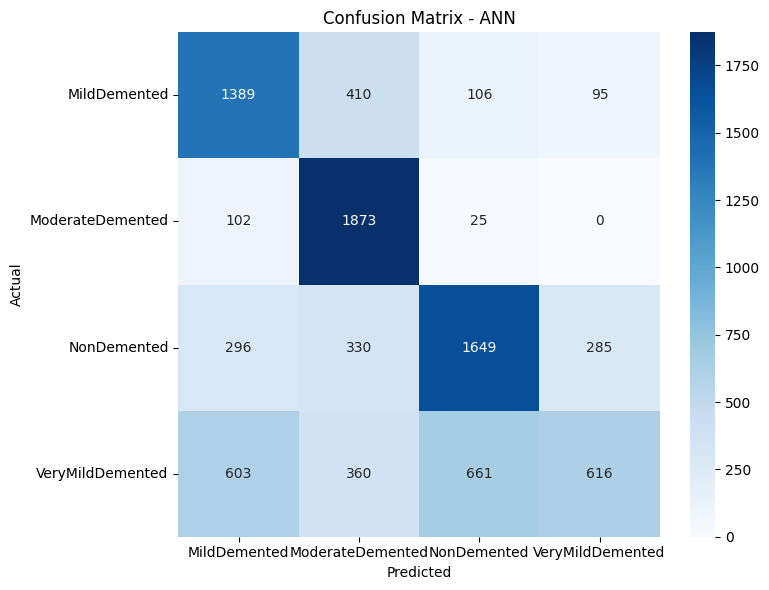

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create NON-SHUFFLED validation data
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_data_fixed = val_datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Predictions
y_pred = model_ann.predict(val_data_fixed)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data_fixed.classes
class_names = list(val_data_fixed.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print("="*40)
print("   KPI Matrix - ANN")
print("="*40)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print("="*40)

   KPI Matrix - ANN
  Accuracy  : 62.81%
  Precision : 62.92%
  Recall    : 62.81%
  F1 Score  : 60.38%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


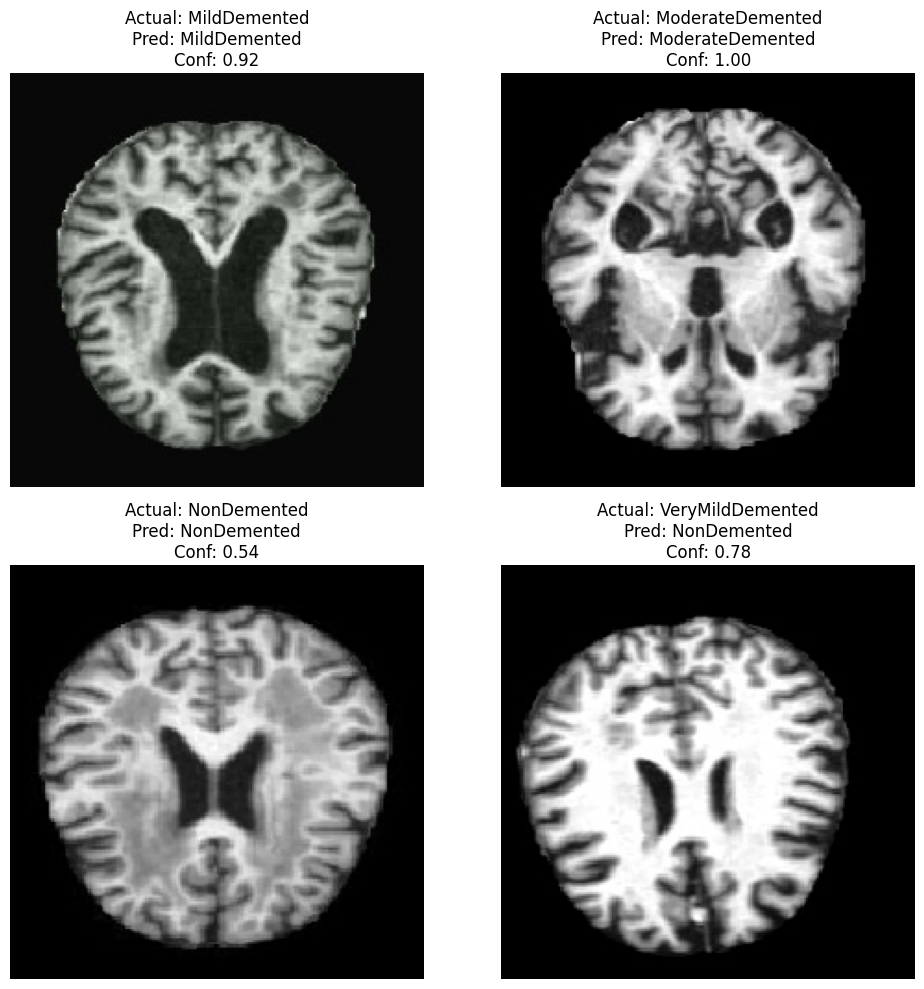

In [9]:
import matplotlib.pyplot as plt
import numpy as np

classes = list(val_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i, class_name in enumerate(classes):
    found = False

    for x_batch, y_batch in val_data:
        for j in range(len(y_batch)):
            if np.argmax(y_batch[j]) == i:
                img = x_batch[j]
                true_label = i

                pred = model_ann.predict(np.expand_dims(img, axis=0))
                pred_label = np.argmax(pred)
                confidence = np.max(pred)

                img_display = (img - img.min()) / (img.max() - img.min())

                plt.subplot(2,2,i+1)
                plt.imshow(img_display)
                plt.title(f"Actual: {classes[true_label]}\nPred: {classes[pred_label]}\nConf: {confidence:.2f}")
                plt.axis('off')

                found = True
                break
        if found:
            break

plt.tight_layout()
plt.show()